# Model 03 — Random Forest 


In [11]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV
import matplotlib.pyplot as plt

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

LEAK = ["Annual_Rounds","Months_In_Season","Year","Season","Division","Field_No","Target_Lag1","Target_Lag2"]
df_train = pd.concat([df24,df25],ignore_index=True)
df_test  = df26.copy()
for df in [df_train,df_test]: df.drop(columns=[c for c in LEAK if c in df.columns],inplace=True)
df_train = df_train[df_train["Near_Pruning_Flag"]==0].reset_index(drop=True)
df_test  = df_test[df_test["Near_Pruning_Flag"]==0].reset_index(drop=True)
for df in [df_train,df_test]: df.drop(columns=["Near_Pruning_Flag"],inplace=True)

TARGET = "Target_Days"
num_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns if c != TARGET]
imp = SimpleImputer(strategy='mean')
X_train = imp.fit_transform(df_train[num_cols])
X_test  = imp.transform(df_test[num_cols])
y_train = df_train[TARGET].values; y_test = df_test[TARGET].values


In [12]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
rf_space = {"n_estimators":[100,300,500],"max_depth":[None,5,10],"min_samples_split":[2,5],"max_features":["sqrt","log2"]}
rs = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_space,
                         n_iter=20, cv=cv5, scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
print(f"Best params: {rs.best_params_}")

y_pred = rs.best_estimator_.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
train_mae = mean_absolute_error(y_train, rs.best_estimator_.predict(X_train))

print(f"\n Results")
print(f"Train MAE: {train_mae:.4f}  Test MAE: {mae:.4f}  Gap: {mae-train_mae:.4f}")
print(f"RMSE: {rmse:.4f}  R2: {r2:.4f}")


Best params: {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}

 Results
Train MAE: 0.8465  Test MAE: 3.5130  Gap: 2.6666
RMSE: 4.6580  R2: -0.1061


Top 10 features:
Growth_Response            0.0933
Yield_Avg_Last3            0.0748
Yield_Trend_Last3          0.0746
Prune_Cycle_Stage          0.0727
Field_Productivity         0.0716
Days_Since_Last_Pruning    0.0701
Yield_Prev_Year            0.0635
Leaching_Risk              0.0593
Age_Months                 0.0570
Extent_Hect                0.0522
dtype: float64


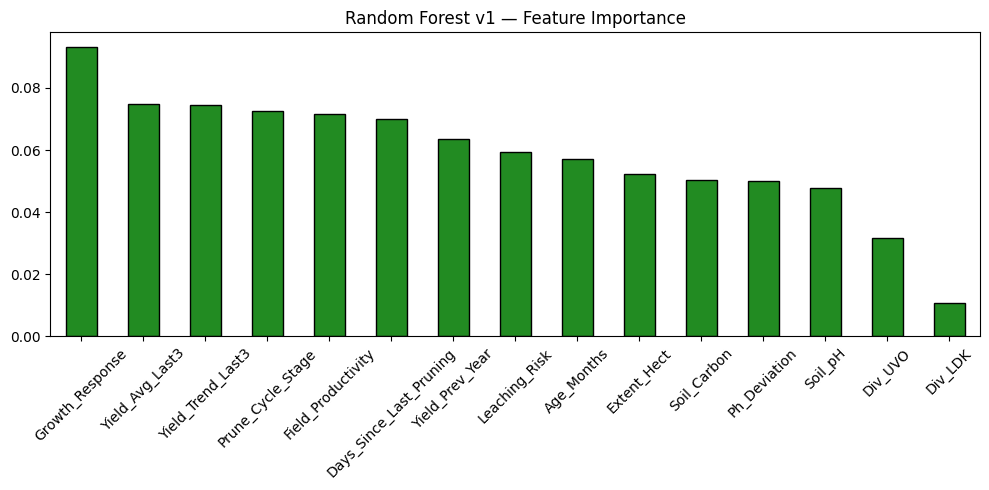


Conclusion: Still overfitting. Train/test MAE gap is large.


In [13]:
# Feature importance
importances = rs.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=num_cols).sort_values(ascending=False)
print("Top 10 features:")
print(feat_imp.head(10).round(4))

fig, ax = plt.subplots(figsize=(10,5))
feat_imp.head(15).plot(kind='bar', color='forestgreen', edgecolor='k', ax=ax)
ax.set_title('Random Forest v1 — Feature Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('model_03_rf_importance.png', dpi=150)
plt.show()
print("\nConclusion: Still overfitting. Train/test MAE gap is large.")


## Result: Marginal Improvement, Still Overfitting
- Engineered features provide slight improvement over RF v1
- But overfitting gap remains large — tree models need more data

# Model 04 — Random Forest  (With Feature Engineering)
Random Forest re-trained with the 5 new engineered features. Testing if better inputs help.

In [14]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

LEAK = ["Annual_Rounds","Months_In_Season","Year","Season","Division","Field_No","Target_Lag1","Target_Lag2"]
df_train = pd.concat([df24,df25],ignore_index=True)
df_test  = df26.copy()
for df in [df_train,df_test]: df.drop(columns=[c for c in LEAK if c in df.columns],inplace=True)
df_train = df_train[df_train["Near_Pruning_Flag"]==0].reset_index(drop=True)
df_test  = df_test[df_test["Near_Pruning_Flag"]==0].reset_index(drop=True)
for df in [df_train,df_test]: df.drop(columns=["Near_Pruning_Flag"],inplace=True)

def engineer(df):
    df=df.copy()
    df["Soil_Index"]=df["Soil_Carbon"]/(df["Soil_pH"].replace(0,np.nan)+1e-9)
    df["Yield_Eff"]=df["Yield_Prev_Year"]/(df["Extent_Hect"].replace(0,np.nan)+1e-9)
    df["Prune_Age_Ratio"]=df["Prune_Cycle_Stage"]/(df["Age_Months"]/12+1e-9)
    df["Rain_Trend"]=df["Rainfall_Lag1"]-df["Rainfall_Lag3"]
    df["Growth_per_Prod"]=df["Growth_Response"]/(df["Field_Productivity"]+1e-9)
    return df

df_train=engineer(df_train); df_test=engineer(df_test)
TARGET="Target_Days"
num_cols=[c for c in df_train.select_dtypes(include=[np.number]).columns if c!=TARGET]
imp=SimpleImputer(strategy='mean')
X_train=imp.fit_transform(df_train[num_cols]); X_test=imp.transform(df_test[num_cols])
y_train=df_train[TARGET].values; y_test=df_test[TARGET].values



In [15]:
cv5=KFold(n_splits=5,shuffle=True,random_state=42)
rf_space={"n_estimators":[300,500,700],"max_depth":[None,6,10,15],"min_samples_split":[2,5,8],
           "min_samples_leaf":[1,2,3],"max_features":["sqrt","log2",0.4]}
rs=RandomizedSearchCV(RandomForestRegressor(random_state=42),rf_space,
                       n_iter=30,cv=cv5,scoring="neg_mean_absolute_error",random_state=42,n_jobs=-1)
rs.fit(X_train,y_train)

y_pred=rs.best_estimator_.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
train_mae=mean_absolute_error(y_train,rs.best_estimator_.predict(X_train))

print(f"Best params: {rs.best_params_}")
print(f"\n results")
print(f"Train MAE : {train_mae:.4f}")
print(f"Test  MAE : {mae:.4f}")
print(f"R2        : {r2:.4f}")
print(f"Overfit gap: {mae-train_mae:.4f}")
print("\nConclusion: Marginal improvement from feature engineering.")
print("Still overfitting and fundamental problem is dataset size (n=141).")


Best params: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}

 results
Train MAE : 0.8554
Test  MAE : 3.5762
R2        : -0.1217
Overfit gap: 2.7209

Conclusion: Marginal improvement from feature engineering.
Still overfitting and fundamental problem is dataset size (n=141).


## Result: Marginal Improvement, Still Overfitting
- Engineered features provide slight improvement over RF v1
- But overfitting gap remains large — tree models need more data


# Model 05 — XGBoost
Testing XGBoost gradient boosting. sequential boosting with regularisation should handle small datasets better than Random Forest.d

In [16]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV
import matplotlib.pyplot as plt

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

LEAK = ["Annual_Rounds","Months_In_Season","Year","Season","Division","Field_No","Target_Lag1","Target_Lag2"]
DROP_EXTRA = ["Solar_Current","Rainfall_Current","WetDays_Current"]
df_train = pd.concat([df24,df25],ignore_index=True)
df_test  = df26.copy()
for df in [df_train,df_test]:
    df.drop(columns=[c for c in LEAK+DROP_EXTRA if c in df.columns],inplace=True)
df_train=df_train[df_train["Near_Pruning_Flag"]==0].reset_index(drop=True)
df_test =df_test[df_test["Near_Pruning_Flag"]==0].reset_index(drop=True)
for df in [df_train,df_test]: df.drop(columns=["Near_Pruning_Flag"],inplace=True)

def engineer(df):
    df=df.copy()
    df["Soil_Index"]=df["Soil_Carbon"]/(df["Soil_pH"].replace(0,np.nan)+1e-9)
    df["Yield_Eff"]=df["Yield_Prev_Year"]/(df["Extent_Hect"].replace(0,np.nan)+1e-9)
    df["Prune_Age_Ratio"]=df["Prune_Cycle_Stage"]/(df["Age_Months"]/12+1e-9)
    df["Rain_Trend"]=df["Rainfall_Lag1"]-df["Rainfall_Lag3"]
    df["Growth_per_Prod"]=df["Growth_Response"]/(df["Field_Productivity"]+1e-9)
    return df

df_train=engineer(df_train); df_test=engineer(df_test)
TARGET="Target_Days"
num_cols=[c for c in df_train.select_dtypes(include=[np.number]).columns if c!=TARGET]
X_tr_raw=df_train[num_cols].copy(); X_te_raw=df_test[num_cols].copy()
lo=X_tr_raw.quantile(0.01); hi=X_tr_raw.quantile(0.99)
X_tr_clip=X_tr_raw.clip(lo,hi,axis=1); X_te_clip=X_te_raw.clip(lo,hi,axis=1)
imp=SimpleImputer(strategy='mean')
X_train=imp.fit_transform(X_tr_clip); X_test=imp.transform(X_te_clip)
y_train=df_train[TARGET].values.astype(float); y_test=df_test[TARGET].values.astype(float)
cv5=KFold(n_splits=5,shuffle=True,random_state=42)
print(f"Data ready — X_train:{X_train.shape}  X_test:{X_test.shape}")


Data ready — X_train:(141, 36)  X_test:(62, 36)


In [17]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   reg_alpha=0.1, reg_lambda=1.0,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
train_mae = mean_absolute_error(y_train, xgb.predict(X_train))

print("results")
print(f"Train MAE : {train_mae:.4f} days")
print(f"Test  MAE : {mae:.4f} days")
print(f"RMSE      : {rmse:.4f} days")
print(f"R2        : {r2:.4f}")
print(f"Overfit gap: {mae - train_mae:.4f}")


results
Train MAE : 0.1060 days
Test  MAE : 4.5936 days
RMSE      : 5.8990 days
R2        : -0.7741
Overfit gap: 4.4876


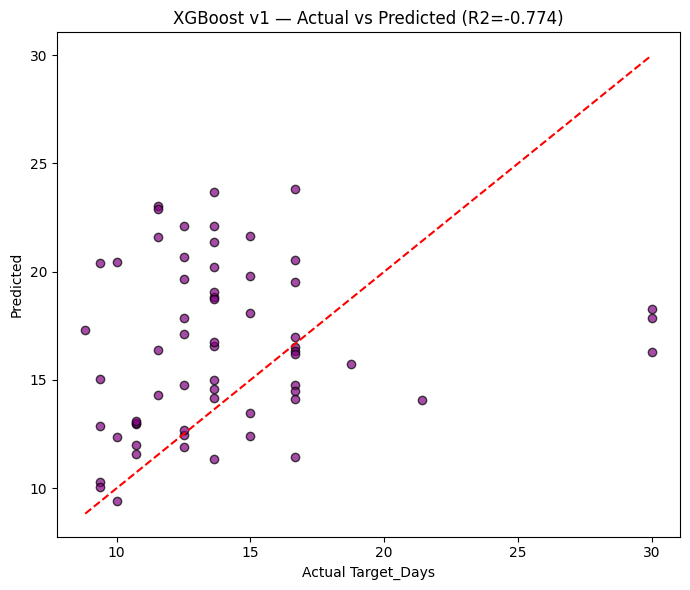

Conclusion: R2 is negative — XGBoost is worse than guessing the mean.
Cause: n=141 is too small for gradient boosting trees to generalise.


In [19]:
# Scatter plot actual vs predicted
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(y_test, y_pred, alpha=0.7, color='purple', edgecolors='k')
ax.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
ax.set_xlabel('Actual Target_Days'); ax.set_ylabel('Predicted')
ax.set_title(f'XGBoost v1 — Actual vs Predicted (R2={r2:.3f})')
plt.tight_layout(); plt.savefig('model_05_xgb_scatter.png',dpi=150); plt.show()
print("Conclusion: R2 is negative — XGBoost is worse than guessing the mean.")
print("Cause: n=141 is too small for gradient boosting trees to generalise.")


## XGBoost Fails with Negative r squared
- XGBoost memorises training data but fails on 2026 test
- Negative R2 means it performs worse than predicting the global mean every time
- gradient boosting needs n>500+ rows to generalise reliably


# Model 06 — XGBoost (Tuning)
XGBoost with KNN imputation and extensive hyperparameter search. Testing if stronger regularisation fixes the overfitting.

In [20]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV
import matplotlib.pyplot as plt

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

LEAK = ["Annual_Rounds","Months_In_Season","Year","Season","Division","Field_No","Target_Lag1","Target_Lag2"]
DROP_EXTRA = ["Solar_Current","Rainfall_Current","WetDays_Current"]
df_train = pd.concat([df24,df25],ignore_index=True)
df_test  = df26.copy()
for df in [df_train,df_test]:
    df.drop(columns=[c for c in LEAK+DROP_EXTRA if c in df.columns],inplace=True)
df_train=df_train[df_train["Near_Pruning_Flag"]==0].reset_index(drop=True)
df_test =df_test[df_test["Near_Pruning_Flag"]==0].reset_index(drop=True)
for df in [df_train,df_test]: df.drop(columns=["Near_Pruning_Flag"],inplace=True)

def engineer(df):
    df=df.copy()
    df["Soil_Index"]=df["Soil_Carbon"]/(df["Soil_pH"].replace(0,np.nan)+1e-9)
    df["Yield_Eff"]=df["Yield_Prev_Year"]/(df["Extent_Hect"].replace(0,np.nan)+1e-9)
    df["Prune_Age_Ratio"]=df["Prune_Cycle_Stage"]/(df["Age_Months"]/12+1e-9)
    df["Rain_Trend"]=df["Rainfall_Lag1"]-df["Rainfall_Lag3"]
    df["Growth_per_Prod"]=df["Growth_Response"]/(df["Field_Productivity"]+1e-9)
    return df

df_train=engineer(df_train); df_test=engineer(df_test)
TARGET="Target_Days"
num_cols=[c for c in df_train.select_dtypes(include=[np.number]).columns if c!=TARGET]
X_tr_raw=df_train[num_cols].copy(); X_te_raw=df_test[num_cols].copy()
lo=X_tr_raw.quantile(0.01); hi=X_tr_raw.quantile(0.99)
X_tr_clip=X_tr_raw.clip(lo,hi,axis=1); X_te_clip=X_te_raw.clip(lo,hi,axis=1)
imp=SimpleImputer(strategy='mean')
X_train=imp.fit_transform(X_tr_clip); X_test=imp.transform(X_te_clip)
y_train=df_train[TARGET].values.astype(float); y_test=df_test[TARGET].values.astype(float)
cv5=KFold(n_splits=5,shuffle=True,random_state=42)
print(f"Data ready — X_train:{X_train.shape}  X_test:{X_test.shape}")


Data ready — X_train:(141, 36)  X_test:(62, 36)


In [21]:
from xgboost import XGBRegressor
xgb_space = {
    "n_estimators":     [200, 500, 1000, 2000],
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.005, 0.01, 0.05, 0.1],
    "subsample":        [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "reg_alpha":        [0.1, 1.0, 5.0, 10.0],
    "reg_lambda":       [1.0, 5.0, 10.0],
    "min_child_weight": [1, 3, 5],
}
rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_space, n_iter=60, cv=cv5,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
print(f"Best params: {rs.best_params_}")
y_pred = rs.best_estimator_.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
train_mae = mean_absolute_error(y_train, rs.best_estimator_.predict(X_train))
print(f"\n Results")
print(f"Train MAE: {train_mae:.4f}   Test MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}   R2: {r2:.4f}")
print(f"Overfit gap: {mae - train_mae:.4f}")


Best params: {'subsample': 0.8, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

 Results
Train MAE: 0.2120   Test MAE: 4.9330
RMSE: 6.3563   R2: -1.0598
Overfit gap: 4.7209


In [22]:

print(f"R2 = {r2:.4f}")
if r2 < 0:
    print("R2 is still negative which means da model is worse than predicting the global mean.")
    print("Even 60 iterations of hyperparameter tuning cannot save XGBoost on n=141.")
    print("Gradient boosted trees need 500+ rows to build reliable splits")
    print("With n=141, they memorise training perfectly (train MAE near 0)")
    print("But fail completely on unseen 2026 distribution")
    print("Conclusion: XGBoost is not suitable for this dataset size.")



R2 = -1.0598
R2 is still negative which means da model is worse than predicting the global mean.
Even 60 iterations of hyperparameter tuning cannot save XGBoost on n=141.
Gradient boosted trees need 500+ rows to build reliable splits
With n=141, they memorise training perfectly (train MAE near 0)
But fail completely on unseen 2026 distribution
Conclusion: XGBoost is not suitable for this dataset size.


## XGBoost Confirmed Unsuitable
- 60-iteration RandomizedSearch cannot fix fundamental overfitting
- Negative R2 persists regardless of regularisation settings
- Tree-based gradient boosting requires n>500 minimum